<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Python_chapter8_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 時系列データ


東京都 新型コロナウイルス感染症対策サイト  
https://github.com/tokyo-metropolitan-gov/covid19
にあるCOVID-19の判明日別陽性者数の推移のデータ```positive_by_diagnosed.json```を用います(データ・コードともにMITライセンス).

コピーはこちら  
https://drive.google.com/file/d/1I1qPIE8QlEpiOJH9_3BafXS2zjUIH1pA/view?usp=sharing

このjson形式のデータを```covid19_positive_by_diagnosed.json```と名前を変更し、google drive内の```AdDS2020```という名前のフォルダに入れて処理することにする。

いつもどおりgoogle driveを/content/drive/にマウントして...

In [97]:
import json #json形式のデータを扱うためのモジュールをインポートする

In [98]:
!ls /content/drive/My\ Drive/AdDS2020/covid19*json #ファイルがあるかを確認

'/content/drive/My Drive/AdDS2020/covid19_positive_by_diagnosed.json'


In [99]:
## jsonファイルの読み込み
inp = open('/content/drive/My Drive/AdDS2020/covid19_positive_by_diagnosed.json', "r")
raw_data = json.load(inp) #jsonモジュール内のload関数でinpの中身を読み込んでraw_dataという名前をつける

dataを表示してみると...

In [100]:
print(raw_data)
print(len(raw_data))

{'date': '2020/8/29 20:00', 'data': [{'diagnosed_date': '2020-01-23', 'count': 2}, {'diagnosed_date': '2020-01-24', 'count': 0}, {'diagnosed_date': '2020-01-25', 'count': 0}, {'diagnosed_date': '2020-01-26', 'count': 0}, {'diagnosed_date': '2020-01-27', 'count': 0}, {'diagnosed_date': '2020-01-28', 'count': 0}, {'diagnosed_date': '2020-01-29', 'count': 0}, {'diagnosed_date': '2020-01-30', 'count': 1}, {'diagnosed_date': '2020-01-31', 'count': 0}, {'diagnosed_date': '2020-02-01', 'count': 0}, {'diagnosed_date': '2020-02-02', 'count': 0}, {'diagnosed_date': '2020-02-03', 'count': 0}, {'diagnosed_date': '2020-02-04', 'count': 0}, {'diagnosed_date': '2020-02-05', 'count': 0}, {'diagnosed_date': '2020-02-06', 'count': 0}, {'diagnosed_date': '2020-02-07', 'count': 0}, {'diagnosed_date': '2020-02-08', 'count': 0}, {'diagnosed_date': '2020-02-09', 'count': 0}, {'diagnosed_date': '2020-02-10', 'count': 0}, {'diagnosed_date': '2020-02-11', 'count': 0}, {'diagnosed_date': '2020-02-12', 'count': 1

最も外側の階層に'date'と'data'という２つのキーを持った辞書型になっていることがわかります。

(辞書型についてはPython_chapter2_ListLoop.ipynbで扱いました)

dateに関しては、　データファイルを更新した日時ですので、'data'の部分だけを使うこととしましょう。

In [101]:
print(raw_data["data"])

[{'diagnosed_date': '2020-01-23', 'count': 2}, {'diagnosed_date': '2020-01-24', 'count': 0}, {'diagnosed_date': '2020-01-25', 'count': 0}, {'diagnosed_date': '2020-01-26', 'count': 0}, {'diagnosed_date': '2020-01-27', 'count': 0}, {'diagnosed_date': '2020-01-28', 'count': 0}, {'diagnosed_date': '2020-01-29', 'count': 0}, {'diagnosed_date': '2020-01-30', 'count': 1}, {'diagnosed_date': '2020-01-31', 'count': 0}, {'diagnosed_date': '2020-02-01', 'count': 0}, {'diagnosed_date': '2020-02-02', 'count': 0}, {'diagnosed_date': '2020-02-03', 'count': 0}, {'diagnosed_date': '2020-02-04', 'count': 0}, {'diagnosed_date': '2020-02-05', 'count': 0}, {'diagnosed_date': '2020-02-06', 'count': 0}, {'diagnosed_date': '2020-02-07', 'count': 0}, {'diagnosed_date': '2020-02-08', 'count': 0}, {'diagnosed_date': '2020-02-09', 'count': 0}, {'diagnosed_date': '2020-02-10', 'count': 0}, {'diagnosed_date': '2020-02-11', 'count': 0}, {'diagnosed_date': '2020-02-12', 'count': 1}, {'diagnosed_date': '2020-02-13', 

さらにいうと、今の場合は１つのファイルのみを扱うので、どの値が何を表すのかは以下の通りで:  
diagnosed_data(陽性が判明した日), count(該当数)です。
したがって、見た目もスッキリするので、日付とカウントそれぞれのリストにしてしまっても問題はないでしょう。

In [102]:
l_date = [] 
l_count = [] 
for tmp in raw_data["data"]:
    l_date += [ tmp["diagnosed_date"] ]
    l_count +=[ tmp["count"] ]
print(l_count)

[2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 7, 5, 1, 3, 4, 0, 4, 0, 0, 3, 0, 4, 0, 0, 1, 1, 0, 2, 4, 4, 7, 6, 1, 0, 4, 4, 4, 6, 5, 3, 4, 10, 10, 9, 8, 7, 4, 19, 29, 47, 35, 54, 62, 55, 52, 63, 109, 88, 155, 134, 85, 85, 132, 198, 266, 190, 235, 147, 188, 129, 190, 226, 196, 157, 91, 113, 113, 130, 115, 116, 107, 61, 69, 99, 66, 101, 56, 77, 60, 39, 32, 23, 25, 22, 34, 28, 11, 11, 20, 12, 10, 8, 3, 7, 2, 11, 4, 8, 6, 7, 8, 12, 16, 21, 19, 7, 15, 20, 10, 33, 20, 25, 24, 10, 10, 25, 22, 43, 42, 45, 21, 14, 28, 26, 61, 32, 30, 18, 32, 51, 54, 53, 68, 53, 64, 49, 70, 103, 127, 138, 131, 98, 82, 98, 258, 232, 221, 201, 104, 155, 173, 298, 305, 299, 238, 139, 217, 246, 397, 291, 254, 198, 109, 241, 274, 459, 406, 477, 362, 219, 266, 320, 433, 441, 383, 357, 225, 122, 206, 248, 432, 298, 273, 141, 146, 247, 299, 313, 284, 180, 105, 150, 210, 268, 192, 164]


図にするとこんなかんじ

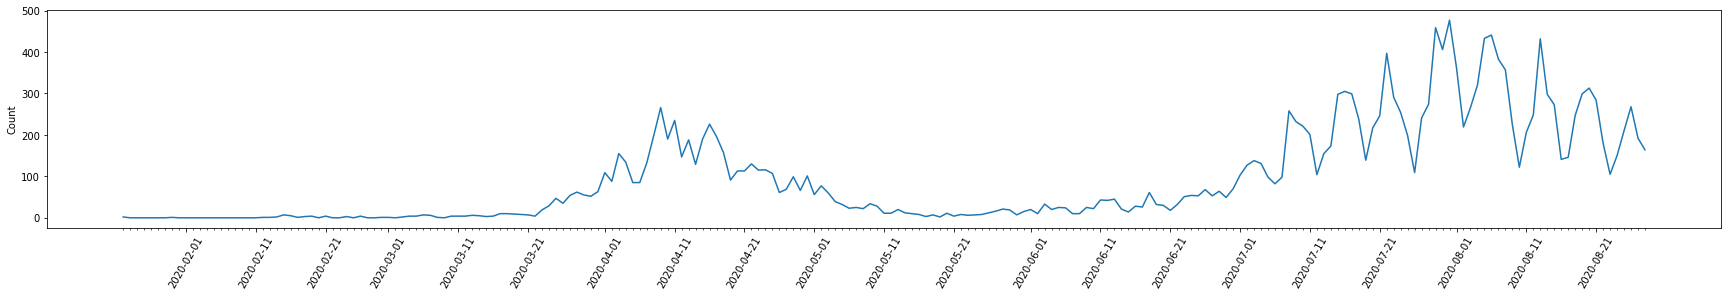

In [103]:
### 日付を全部x軸に書くとごちゃごちゃするので間引く 
Mlabel = []; Mticks=[]
for i,tmp in enumerate(l_date):
    day = tmp.split("-")[-1]
    if day =="01" or day == "11" or day == "21":
        Mlabel += [tmp]
        Mticks += [i]

from matplotlib import pyplot as plt 
import matplotlib.dates as mdates
fig=plt.figure(figsize=(30,4))
ax = fig.add_subplot(111)
ax.plot(l_date,l_count)
ax.set_xticks(ax.get_xticks(), minor=True) #Minor目盛:1日ごと
ax.set_xticks(Mticks, minor=False) # Major目盛:特定の日にち(01/11/21)ごと
ax.set_xticklabels(Mlabel, rotation='60',minor=False)
ax.set_ylabel("Count")
plt.show()
plt.close()

単純移動平均の算出

In [114]:
import numpy as np
def MA(data, period):
    ma = np.zeros(len(data))
    ma[:] = np.nan 
    for i in range(period,len(data)):        
        ma[i] = np.mean([data[i-j] for j in range(period)])
    return ma

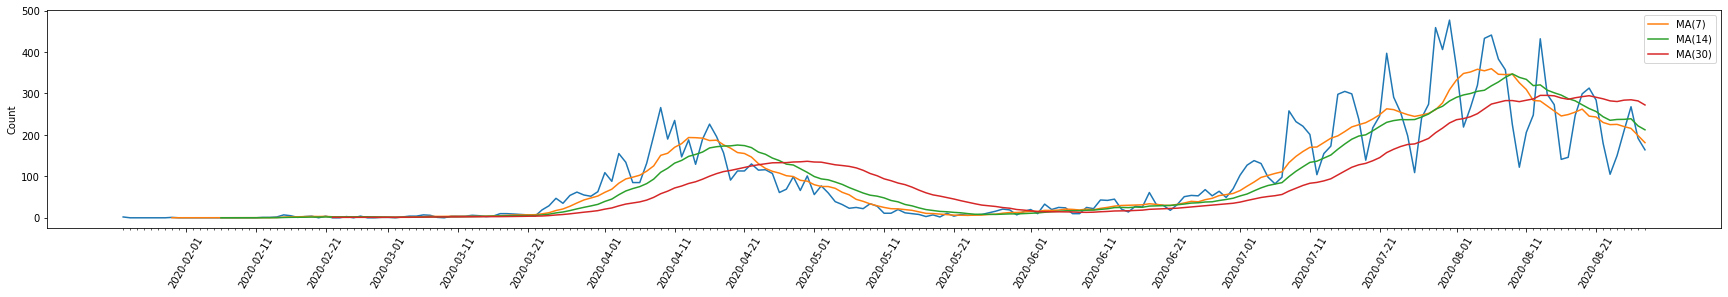

In [113]:
## 先程のplotに移動平均(7日,14日,30日)を重ねる
Mlabel = []; Mticks=[]
for i,tmp in enumerate(l_date):
    day = tmp.split("-")[-1]
    if day =="01" or day == "11" or day == "21":
        Mlabel += [tmp]
        Mticks += [i]

from matplotlib import pyplot as plt 
import matplotlib.dates as mdates
fig=plt.figure(figsize=(30,4))
ax = fig.add_subplot(111)
ax.plot(l_date,l_count)
ax.plot(l_date,MA(l_count,7),label="MA(7)")
ax.plot(l_date,MA(l_count,14),label="MA(14)")
ax.plot(l_date,MA(l_count,30),label="MA(30)")
ax.set_xticks(ax.get_xticks(), minor=True) #Minor目盛:1日ごと
ax.set_xticks(Mticks, minor=False) # Major目盛:特定の日にち(01/11/21)ごと
ax.set_xticklabels(Mlabel, rotation='60',minor=False)
ax.set_ylabel("Count")
ax.legend()
plt.show()
plt.close()